In [1]:
%pip install pymoo


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import joblib

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize

In [5]:
energy_model = joblib.load("energy_model.pkl")
yield_model = joblib.load("yield_model.pkl")
quality_model = joblib.load("quality_model.pkl")

In [6]:
def calculate_carbon(energy):
    emission_factor = 0.82
    return energy * emission_factor

In [ ]:
class ManufacturingOptimization(Problem):

    def __init__(self):
        super().__init__(
            n_var=7,
            n_obj=4,
            n_constr=0,
            xl=np.array([120, 0.8, 30, 10, 50, 5, 0]),
            xu=np.array([180, 1.2, 80, 40, 200, 20, 5])
        )

    def _evaluate(self, X, out, *args, **kwargs):

        results = []

        for row in X:

            # Create dictionary for process parameters
            data = {
                "Temperature_C": row[0],
                "Pressure_Bar": row[1],
                "Humidity_Percent": row[2],
                "Motor_Speed_RPM": row[3],
                "Compression_Force_kN": row[4],
                "Flow_Rate_LPM": row[5],
                "Vibration_mm_s": row[6],
            }

            # Add all phase columns automatically; zero them out
            phase_cols = [col for col in energy_model.feature_names_in_ if col.startswith("Phase_")]
            for col in phase_cols:
                data[col] = 0

            # choose a default phase (first available) to avoid all-zero vector
            if phase_cols:
                data[phase_cols[0]] = 1

            # Create dataframe in correct order
            features = pd.DataFrame([data])[energy_model.feature_names_in_]

            # Predictions
            energy = energy_model.predict(features)[0]
            yield_val = yield_model.predict(features)[0]
            quality = quality_model.predict(features)[0]

            # Carbon emission
            carbon = calculate_carbon(energy)

            results.append([
                energy,
                carbon,
                -yield_val,
                -quality
            ])

        out["F"] = np.array(results)

In [8]:
problem = ManufacturingOptimization()

In [9]:
algorithm = NSGA2(
    pop_size=50
)

In [10]:
result = minimize(
    problem,
    algorithm,
    ('n_gen', 40),
    seed=1,
    verbose=True
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       50 |     35 |             - |             -
     2 |      100 |     50 |  0.0046026010 |         nadir
     3 |      150 |     50 |  0.0098962723 |             f
     4 |      200 |     50 |  0.0086689500 |             f
     5 |      250 |     50 |  0.0061920037 |             f
     6 |      300 |     50 |  0.0033022587 |         nadir
     7 |      350 |     50 |  0.0044189665 |             f
     8 |      400 |     50 |  0.0082465794 |             f
     9 |      450 |     50 |  0.0081540165 |             f
    10 |      500 |     50 |  0.0060564896 |             f
    11 |      550 |     50 |  0.0037059416 |             f
    12 |      600 |     50 |  0.0056255962 |             f
    13 |      650 |     50 |  0.0039968423 |         ideal
    14 |      700 |     50 |  0.0042440147 |             f
    15 |      750 |     50 |  0.0066109647 |             f
    16 |      800 |     50 |  0.0066996454 |         nad

In [12]:
pareto_solutions = result.X
pareto_objectives = result.F

print("Parameter Sets:")
print(pareto_solutions)

print("\nObjective Values:")
print(pareto_objectives)

Parameter Sets:
[[148.04692321   1.09518849  63.80243386  13.31446617  84.65350209
    5.26902087   0.19987402]
 [145.64932902   1.15170275  65.13725771  22.07121779  86.01329038
   17.58288167   4.9253242 ]
 [148.04692321   1.09518849  63.80243386  13.25484948  84.65350209
    5.26902087   0.19987402]
 [142.63170299   1.1288741   64.14992728  12.78537213  88.72229516
    5.40747363   0.19987402]
 [148.04692321   1.12819284  66.36950682  22.04509157  87.72437027
    5.97999243   4.96120792]
 [142.77716765   1.12384858  64.92962331  22.18412444  86.65603387
    6.52381087   4.96806887]
 [150.45032512   1.1288741   64.17241473  22.08274301  87.88120119
    5.22326068   0.19987402]
 [139.81210325   1.00813203  30.48131243  24.73305829 162.59041605
   17.98550364   3.74893974]
 [146.0790732    1.01054873  65.25700227  11.83725971  87.22449215
    5.78343935   0.92802263]
 [145.80414247   1.005514    65.13340418  11.83725971  86.70125022
   17.52173998   0.92802263]
 [146.08305472   1.01450

In [13]:
columns = [
    "Temperature_C",
    "Pressure_Bar",
    "Humidity_Percent",
    "Motor_Speed_RPM",
    "Compression_Force_kN",
    "Flow_Rate_LPM",
    "Vibration_mm_s"
]

pareto_df = pd.DataFrame(pareto_solutions, columns=columns)

pareto_df.head()

,Temperature_C,Pressure_Bar,Humidity_Percent,Motor_Speed_RPM,Compression_Force_kN,Flow_Rate_LPM,Vibration_mm_s
0,148.046923,1.095188,63.802434,13.314466,84.653502,5.269021,0.199874
1,145.649329,1.151703,65.137258,22.071218,86.013290,17.582882,4.925324
2,148.046923,1.095188,63.802434,13.254849,84.653502,5.269021,0.199874
3,142.631703,1.128874,64.149927,12.785372,88.722295,5.407474,0.199874
4,148.046923,1.128193,66.369507,22.045092,87.724370,5.979992,4.961208


In [14]:
energy_list = []
yield_list = []
quality_list = []
carbon_list = []

for i in range(len(pareto_df)):

    row = pareto_df.iloc[i]

    data = row.to_dict()

    # Add phase columns automatically
    for col in energy_model.feature_names_in_:
        if col.startswith("Phase_"):
            data[col] = 0

    data["Phase_0"] = 1

    features = pd.DataFrame([data])[energy_model.feature_names_in_]

    energy = energy_model.predict(features)[0]
    yield_val = yield_model.predict(features)[0]
    quality = quality_model.predict(features)[0]

    carbon = calculate_carbon(energy)

    energy_list.append(energy)
    yield_list.append(yield_val)
    quality_list.append(quality)
    carbon_list.append(carbon)

In [15]:
pareto_df["Energy_kWh"] = energy_list
pareto_df["Yield"] = yield_list
pareto_df["Quality"] = quality_list
pareto_df["Carbon_Emission"] = carbon_list

pareto_df.head()

,Temperature_C,Pressure_Bar,Humidity_Percent,Motor_Speed_RPM,Compression_Force_kN,Flow_Rate_LPM,Vibration_mm_s,Energy_kWh,Yield,Quality,Carbon_Emission
0,148.046923,1.095188,63.802434,13.314466,84.653502,5.269021,0.199874,6.369828,6.333702,5.479075,5.223259
1,145.649329,1.151703,65.137258,22.071218,86.013290,17.582882,4.925324,41.361927,41.706516,40.671395,33.916780
2,148.046923,1.095188,63.802434,13.254849,84.653502,5.269021,0.199874,6.369828,6.333702,5.479075,5.223259
3,142.631703,1.128874,64.149927,12.785372,88.722295,5.407474,0.199874,6.470731,6.332044,5.586660,5.305999
4,148.046923,1.128193,66.369507,22.045092,87.724370,5.979992,4.961208,41.852769,42.403693,40.469116,34.319270


In [16]:
golden_signature = pareto_df.sort_values(
    ["Yield", "Quality", "Energy_kWh"],
    ascending=[False, False, True]
).iloc[0]

print("Golden Signature:")
print(golden_signature)

Golden Signature:
Temperature_C           142.777168
Pressure_Bar              1.123849
Humidity_Percent         64.929623
Motor_Speed_RPM          22.184124
Compression_Force_kN     86.656034
Flow_Rate_LPM             6.523811
Vibration_mm_s            4.968069
Energy_kWh               41.815218
Yield                    42.645971
Quality                  40.390369
Carbon_Emission          34.288479
Name: 5, dtype: float64


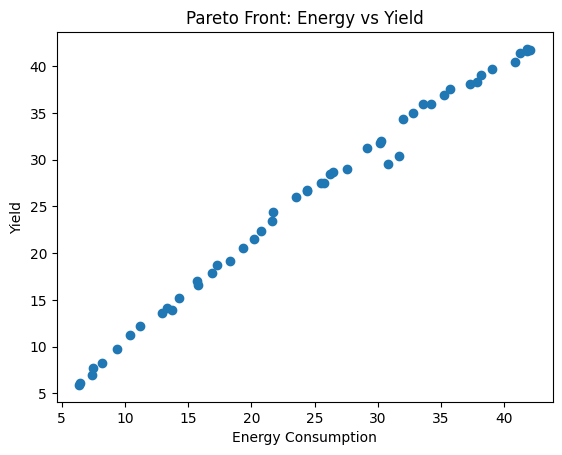

In [26]:
import matplotlib.pyplot as plt

plt.scatter(pareto_df["Energy_kWh"], pareto_df["Yield"])

plt.xlabel("Energy Consumption")
plt.ylabel("Yield")

plt.title("Pareto Front: Energy vs Yield")

plt.show()